# K-Nearest Neighbors (KNN)
K-Nearest Neighbors (KNN) is een eenvoudig en intuïtief machine learning-algoritme dat wordt gebruikt voor zowel classificatie- als regressietaken. Het principe achter KNN is gebaseerd op het idee dat vergelijkbare gegevenspunten zich in de buurt van elkaar bevinden in de feature-ruimte. Bij het classificeren van een nieuw gegevenspunt kijkt KNN naar de 'k' dichtstbijzijnde buren (gegevenspunten) in de trainingsset en wijst het nieuwe punt toe aan de klasse die het meest voorkomt onder deze buren.

In [ ]:
import sys
import os
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

# Add the parent directory (project root) to Python path
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.libs_generic_functions import LibsDataLoader, LibsDataPreprocessor
from utils.baseline_correction_functions import BaselineCorrector, analyze_correction_quality, print_quality_report
from utils.normalization_functions import Normalizer
from utils.pca_analysis_functions import PCAAnalyzer, quick_pca_analysis

Libraries imported successfully!


Voordat we KNN goed kunnen gebruiken moeten wij dimensionaliteitsreductie toepassen. Dit is omdat KNN veel moeite heeft met "The curse of dimensionality", oftewel dimensionaliteitsvloek. De data bestaat namelijk uit een set van (51453, 8188). KNN zal hier niet goed kunnen classificeren. 

Hierbij zullen wij LDA en PCA testen

In [2]:
%%time
df = pd.read_csv("../data/csv/processed_data.csv")

CPU times: total: 1min 38s
Wall time: 1min 39s


In [3]:
%%time
Preprocessor = LibsDataPreprocessor()
X_train, X_test, y_train, y_test, label_encoder, wavelength_columns = Preprocessor.prepare_ml_data(df)

PREPARING DATA FOR MACHINE LEARNING
Original dataset shape: (51453, 8191)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Splitting complete dataset (test_size=0.2, random_state=42)...
Training dataset shape: (41162, 8191)
Test dataset shape: (10291, 8191)
Training target distribution:
origin
tread         14349
innerliner    13808
sidewall      13005
Name: count, dtype: int64
Test target distribution:
origin
tread         3587
innerliner    3452
sidewall      3252
Name: count, dtype: int64
Training dataset shape: (41162, 8191)
Test dataset shape: (10291, 8191)
Training target distribution:
origin
tread         14349
innerliner    13808
sidewall      13005
Name: count, dtype: int64
Test target distribution:
origin
tread         3587
innerliner    3452
sidewall      3252
Name: count, dtype: int64

Identified 8188 wavelength columns
Extracting features and targets from training set...

Identified 8188 wavelength columns
E

Normalizing features...
Applying SNV normalization to dataset:
  - Samples: 41162
  - Verification (first spectrum): mean=0.000000, std=1.000000
  - SNV normalization completed successfully!
Applying SNV normalization to dataset:
  - Samples: 10291
  - Verification (first spectrum): mean=0.000000, std=1.000000
  - SNV normalization completed successfully!
Applying SNV normalization to dataset:
  - Samples: 10291
  - Verification (first spectrum): mean=-0.000000, std=1.000000
  - SNV normalization completed successfully!
Data preprocessing completed successfully!
  - Verification (first spectrum): mean=-0.000000, std=1.000000
  - SNV normalization completed successfully!
Data preprocessing completed successfully!


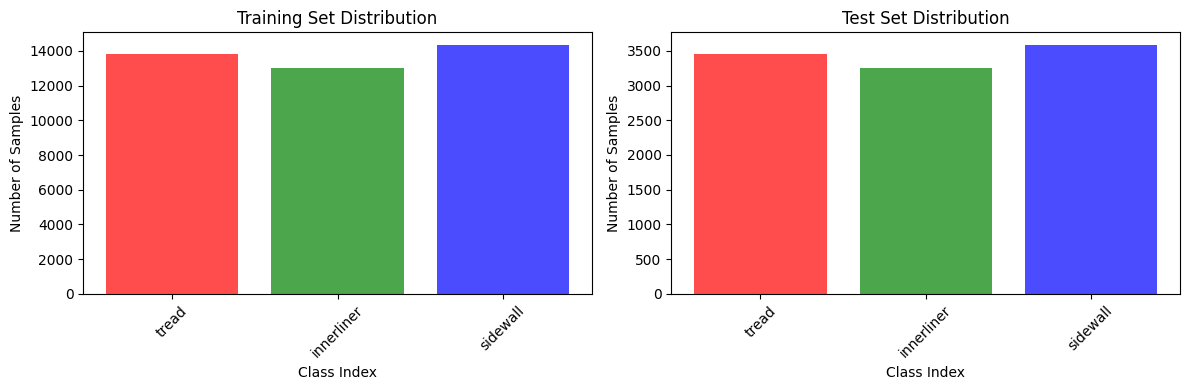

In [ ]:
%%time
# Feature normalization 
print("Normalizing features...")
normaliser = Normalizer()
X_train_scaled = normaliser.apply_standard_normal_variate_on_dataset(X_train)
X_test_scaled = normaliser.apply_standard_normal_variate_on_dataset(X_test)
print("Data preprocessing completed successfully!")

# Display train/test distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Training set distribution
train_unique, train_counts = np.unique(y_train, return_counts=True)
ax1.bar(range(len(train_unique)), train_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax1.set_title('Training Set Distribution')
ax1.set_xlabel('Class Index')
ax1.set_ylabel('Number of Samples')
ax1.set_xticks(range(len(train_unique)))
ax1.set_xticklabels(("tread", "innerliner", "sidewall"), rotation=45)

# Test set distribution  
test_unique, test_counts = np.unique(y_test, return_counts=True)
ax2.bar(range(len(test_unique)), test_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax2.set_title('Test Set Distribution')
ax2.set_xlabel('Class Index')
ax2.set_ylabel('Number of Samples')
ax2.set_xticks(range(len(test_unique)))
ax2.set_xticklabels(("tread", "innerliner", "sidewall"), rotation=45)

plt.tight_layout()
plt.show()

## 1. KNN op originele features

In [ ]:
%%time
# 1. KNN on Original Features
print("=" * 60)
print("1. KNN Classification on Original Features")
print("=" * 60)

# Find optimal k using cross-validation
k_range = range(1, 21)
cv_scores = []

print("Finding optimal k parameter...")
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Find best k
optimal_k = k_range[np.argmax(cv_scores)]
print(f"Optimal k: {optimal_k}")

# Plot k selection
plt.figure(figsize=(10, 6))
plt.plot(k_range, cv_scores, marker='o')
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
plt.title('KNN Cross-Validation Accuracy vs k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Train final model with optimal k
knn_original = KNeighborsClassifier(n_neighbors=optimal_k)
knn_original.fit(X_train_scaled, y_train)

# Make predictions
y_pred_original = knn_original.predict(X_test_scaled)

# Calculate accuracy
accuracy_original = accuracy_score(y_test, y_pred_original)
print(f"\nKNN Accuracy on Original Features: {accuracy_original:.4f}")

# Classification report
print("\nClassification Report (Original Features):")
print(classification_report(y_test, y_pred_original, 
                          target_names=label_encoder.classes_))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm_original = confusion_matrix(y_test, y_pred_original)
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - KNN on Original Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 2. KNN op PCA gereduceerde features

2. PCA Analysis and KNN on PCA Features
🚀 Starting quick PCA analysis...
Step 1: Fitting PCA analysis...
Performing comprehensive PCA analysis...


✅ PCA analysis completed successfully
   Components for 95% variance: 3027
   Components for 99% variance: 4760
Step 2: Evaluating performance...

🔍 Starting PCA performance evaluation...
Evaluating KNN performance with PCA...
Testing components: [100, 200, 3027, 4760]
  Testing with 100 components...
    ✅ KNN with 100 components: 0.9447 (0.581 variance explained)
  Testing with 200 components...
    ✅ KNN with 200 components: 0.9481 (0.607 variance explained)
  Testing with 3027 components...
    ✅ KNN with 3027 components: 0.8535 (0.949 variance explained)
  Testing with 4760 components...
    ✅ KNN with 4760 components: 0.8404 (0.990 variance explained)

🏆 Best KNN result:
   Components: 200
   Accuracy: 0.9481
   Variance explained: 0.607
✅ Quick PCA analysis completed successfully!

🏆 Best KNN-PCA Configuration:
   Components: 200
   Accuracy: 0.9481
   Variance explained: 0.607

Classification Report (PCA - 200 components):
              precision    recall  f1-score   support



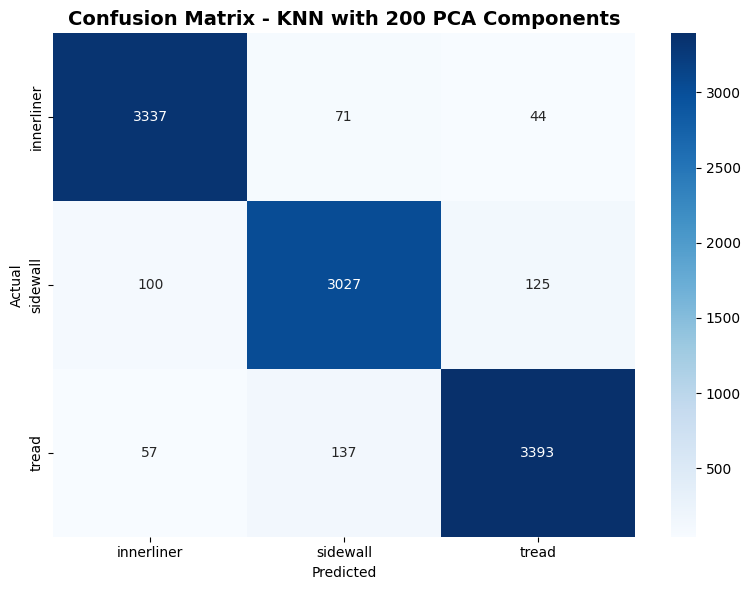


💡 Component Recommendations:
   Speed optimized: 3027 components
   Accuracy optimized: 4760 components
   Balanced: 100 components


In [ ]:
%%time
try:
    # Quick comprehensive PCA analysis with KNN
    result = quick_pca_analysis(
        X_train_scaled, X_test_scaled, y_train, y_test,
        classifier_name='KNN', label_encoder=label_encoder, plot=True
    )
    
    # Safely unpack results
    if isinstance(result, tuple) and len(result) == 3:
        pca_analyzer, analysis_results, knn_results = result
        
        # Check if we have valid results
        if knn_results is not None and 'best_result' in knn_results:
            best_result = knn_results['best_result']
            
            if best_result is not None:
                print(f"\n🏆 Best KNN-PCA Configuration:")
                print(f"   Components: {best_result['n_components']}")
                print(f"   Accuracy: {best_result['accuracy']:.4f}")
                print(f"   Variance explained: {best_result['variance_explained']:.3f}")

                # Classification report for best result
                print(f"\nClassification Report (PCA - {best_result['n_components']} components):")
                print(classification_report(y_test, best_result['y_pred'], 
                                          target_names=label_encoder.classes_))

                # Plot confusion matrix for best result
                pca_analyzer.plot_confusion_matrix(
                    y_test, best_result['y_pred'], 'KNN',
                    best_result['n_components'], label_encoder
                )

                # Get recommendations
                recommendations = pca_analyzer.get_component_recommendations(knn_results)
                if recommendations:
                    print(f"\n💡 Component Recommendations:")
                    print(f"   Speed optimized: {recommendations['speed_optimized']} components")
                    print(f"   Accuracy optimized: {recommendations['accuracy_optimized']} components")
                    if recommendations['balanced']:
                        print(f"   Balanced: {recommendations['balanced']} components")
            else:
                print("❌ No best result found in analysis")
        else:
            print("❌ Invalid or missing KNN results")
    else:
        print(f"❌ Unexpected result type: {type(result)}")
        
except Exception as e:
    print(f"❌ Error in PCA analysis: {e}")
    print(f"Error type: {type(e)}")
    import traceback
    traceback.print_exc()

## 3. KNN op LDA gereduceerde features

Performing LDA analysis...
Number of classes: 3
Maximum LDA components: 2
Class labels: ['innerliner' 'sidewall' 'tread']
LDA with 1 component(s):
  - Explained variance ratio: [0.6291922]
  - Total variance explained: 0.6292
LDA with 1 component(s):
  - Explained variance ratio: [0.6291922]
  - Total variance explained: 0.6292
LDA with 2 component(s):
  - Explained variance ratio: [0.6291922  0.37080783]
  - Total variance explained: 1.0000
Testing KNN with different LDA component numbers...
Component options: [1, 2]

Evaluating 1 components...
LDA with 2 component(s):
  - Explained variance ratio: [0.6291922  0.37080783]
  - Total variance explained: 1.0000
Testing KNN with different LDA component numbers...
Component options: [1, 2]

Evaluating 1 components...
LDA transformed shape: (41162, 1)
Explained variance ratio: [0.6291922]
Total variance explained: 0.6292
Optimizing KNN hyperparameters...
LDA transformed shape: (41162, 1)
Explained variance ratio: [0.6291922]
Total variance 

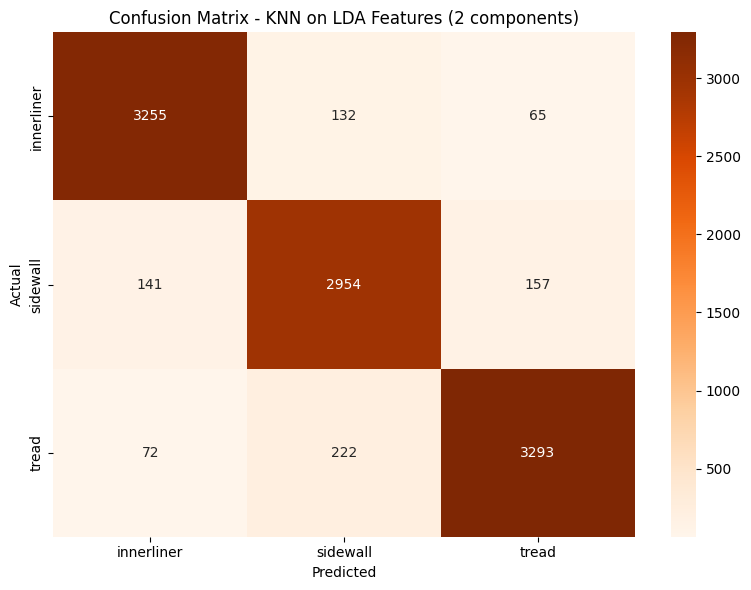

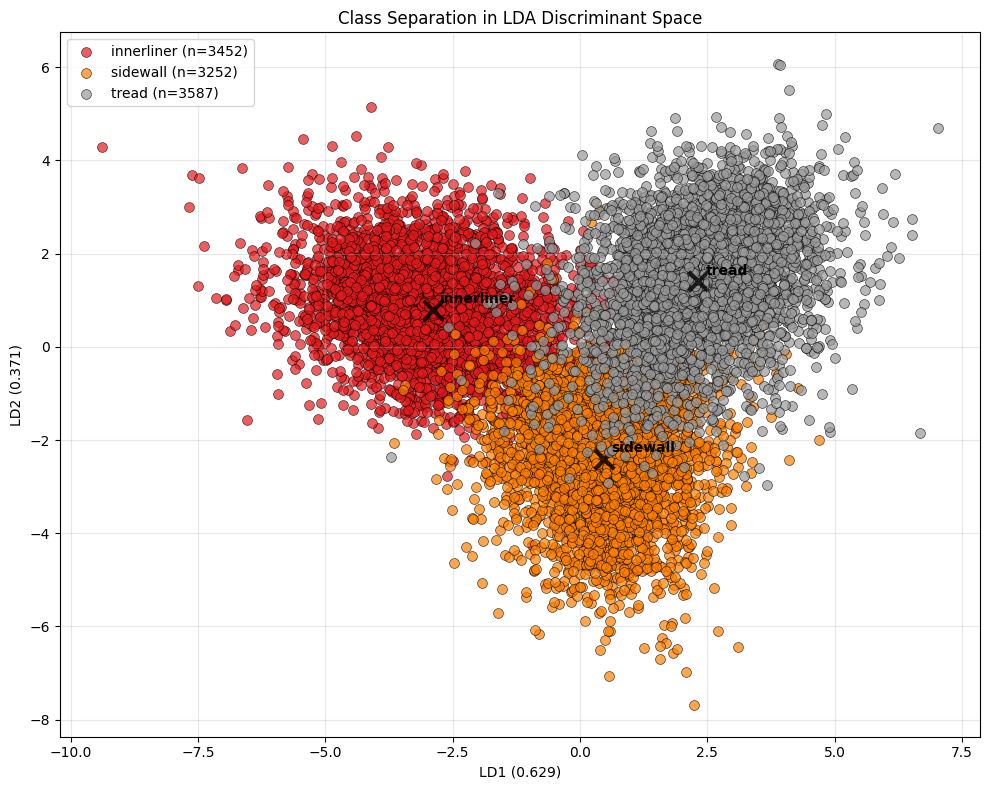

In [9]:
from utils.lda_analysis_functions import quick_lda_analysis

# Quick LDA analysis for KNN
results = quick_lda_analysis(X_train_scaled, X_test_scaled, y_train, y_test, 
                           classifier_name='KNN', label_encoder=label_encoder)

## 4. Conclusie